## TRAINING CODE

In [ ]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:

# Load training dataset

data = pd.read_csv(
r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\train_FD001.txt", sep=" ", header=None)

# drop empty columns
data.drop(columns=[26,27], inplace=True)

# assign column names
columns = [
'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
'Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']
data.columns = columns

print(data.shape)

(20631, 26)


In [25]:

# Remove unnecessary columns

data.drop(columns=[
'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
], inplace=True)

# keep only sensor values
sensor_data = data.drop(columns=['unit_number','time_in_cycles'])

print(sensor_data.head())

   setting_1  setting_2     T24      T30      T50    P15     P30       Nf  \
0    -0.0007    -0.0004  641.82  1589.70  1400.60  21.61  554.36  2388.06   
1     0.0019    -0.0003  642.15  1591.82  1403.14  21.61  553.75  2388.04   
2    -0.0043     0.0003  642.35  1587.99  1404.20  21.61  554.26  2388.08   
3     0.0007     0.0000  642.35  1582.79  1401.87  21.61  554.45  2388.11   
4    -0.0019    -0.0002  642.37  1582.85  1406.22  21.61  554.00  2388.06   

        Nc   Ps30     phi      NRf      NRc     BPR  htBleed    W31      W32  
0  9046.19  47.47  521.66  2388.02  8138.62  8.4195      392  39.06  23.4190  
1  9044.07  47.49  522.28  2388.07  8131.49  8.4318      392  39.00  23.4236  
2  9052.94  47.27  522.42  2388.03  8133.23  8.4178      390  38.95  23.3442  
3  9049.48  47.13  522.86  2388.08  8133.83  8.3682      392  38.88  23.3739  
4  9055.15  47.28  522.19  2388.04  8133.80  8.4294      393  38.90  23.4044  


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
sensor_scaled = scaler.fit_transform(sensor_data)
sensor_scaled = pd.DataFrame(sensor_scaled, columns=sensor_data.columns)

In [27]:

# Create time sequences


def create_sequences(data, seq_len=30):
    seqs = []
    for i in range(len(data) - seq_len):
        seqs.append(data.iloc[i:i+seq_len].values)
    return np.array(seqs)

SEQ_LEN = 30

X = create_sequences(sensor_scaled, SEQ_LEN)

print("Shape:", X.shape)

Shape: (20601, 30, 17)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

### 1D-CNN model

In [29]:
from tensorflow.keras.models import Sequential, load_model
timesteps = X_train.shape[1]
features = X_train.shape[2]

model = Sequential()

# detect local patterns
model.add(Conv1D(32, 3, activation='relu',input_shape=(timesteps, features)))

# reduce size
model.add(MaxPooling1D(2))

# flatten
model.add(Flatten())

# dense learning
model.add(Dense(64, activation='relu'))

# reconstruct output
model.add(Dense(timesteps * features))

model.compile(optimizer='adam', loss='mse')

model.summary()

C:\Users\Chekk\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 28, 32)         │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 510)            │        33,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,550 (248.24 KB)

 Trainable params: 63,550 (248.24 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

# Train model

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat  = X_test.reshape((X_test.shape[0], -1))

model.fit(
    X_train, X_train_flat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, X_test_flat))

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0283 - val_loss: 0.0122
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0105 - val_loss: 0.0103
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - val_loss: 0.0100
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0099 - val_loss: 0.0099
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0098 - val_loss: 0.0097
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0096 - val_loss: 0.0095
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094 - val_loss: 0.0093
Epoch 9/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 10/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0089 - val_loss: 0.0088


In [31]:
# Save model
model.save("cnn_model.keras")

In [32]:

test_data = pd.read_csv(
r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\test_FD001.txt",sep=" ", header=None)

test_data.drop(columns=[26,27], inplace=True)
test_data.columns = columns

In [33]:

# preprocessing

test_data.drop(columns=[
'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)

sensor_test = test_data.drop(columns=['unit_number','time_in_cycles'])

sensor_test_scaled = scaler.transform(sensor_test)
sensor_test_scaled = pd.DataFrame(sensor_test_scaled, columns=sensor_test.columns)
X_test_seq = create_sequences(sensor_test_scaled, SEQ_LEN)

In [34]:
# Prediction
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
model = load_model("cnn_model.keras")

X_pred_flat = model.predict(X_test_seq)

# reshape back
X_pred = X_pred_flat.reshape(X_test_seq.shape)

409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [35]:
# Reconstruction error
error = np.mean((X_test_seq - X_pred)**2, axis=(1,2))

print(error[:10])

[0.00663795 0.00638545 0.00627364 0.00591822 0.00673924 0.00631228
 0.00628554 0.00650133 0.00682629 0.00674838]


In [36]:
# Threshold
threshold = np.percentile(error, 95)

print("Threshold:", threshold)

Threshold: 0.014165634644140656


In [37]:
# Detect anomalies
anomalies = error > threshold

print("Total anomalies:", np.sum(anomalies))

Total anomalies: 654


In [41]:
# Health index
from sklearn.preprocessing import MinMaxScaler
e_min, e_max = error.min(), error.max()

health_index = 1 - (error - e_min) / (e_max - e_min)

health_index = np.clip(health_index, 0, 1)
print(health_index)

[0.90859247 0.92300905 0.92939274 ... 0.90857219 0.89433525 0.87917616]


In [43]:

# Condition classification

def get_condition(HI):
    if HI >= 0.8:
        return "Healthy"
    elif HI >= 0.5:
        return "MODERATE"
    else:
        return "BAD"

# apply to all values
conditions = [get_condition(x) for x in health_index]

# convert to DataFrame for clarity
result_df = pd.DataFrame({
    "Error": error,
    "Health_Index": health_index,
    "Condition": conditions
})

print(result_df.head(10))

      Error  Health_Index Condition
0  0.006638      0.908592   Healthy
1  0.006385      0.923009   Healthy
2  0.006274      0.929393   Healthy
3  0.005918      0.949685   Healthy
4  0.006739      0.902810   Healthy
5  0.006312      0.927186   Healthy
6  0.006286      0.928713   Healthy
7  0.006501      0.916393   Healthy
8  0.006826      0.897839   Healthy
9  0.006748      0.902287   Healthy


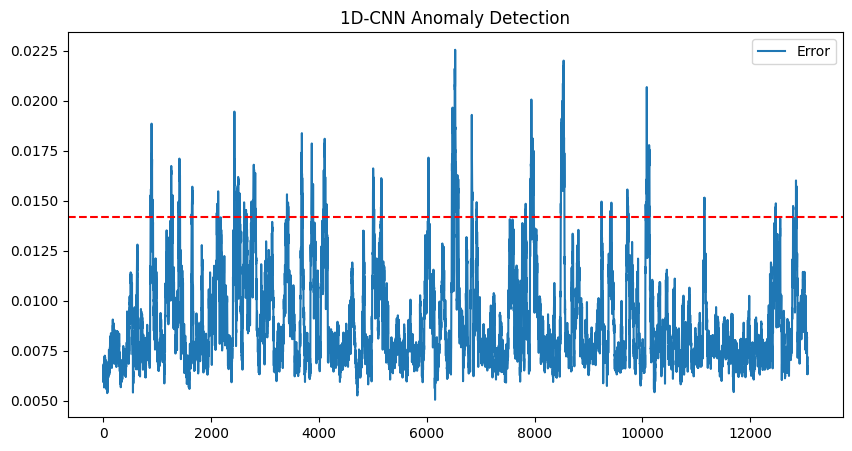

In [46]:

plt.figure(figsize=(10,5))

plt.plot(error, label="Error")
plt.axhline(threshold, color='red', linestyle='--')

plt.legend()
plt.title("1D-CNN Anomaly Detection")
plt.show()

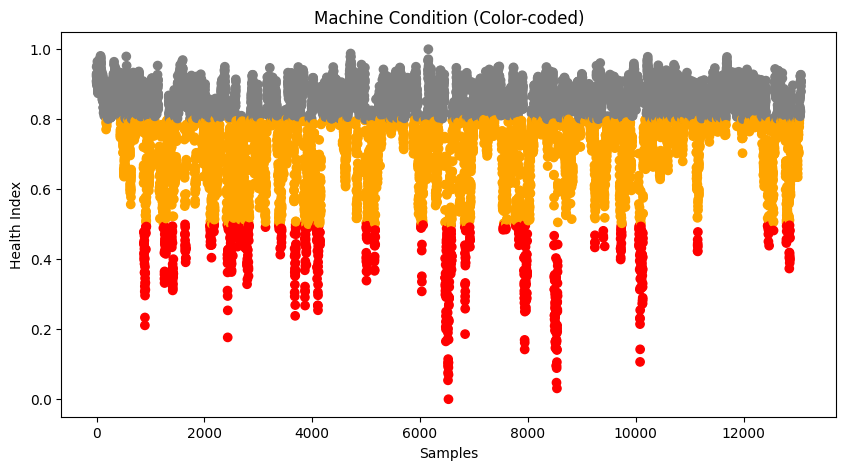

In [48]:
plt.figure(figsize=(10,5))
colors = result_df["Condition"].map({
    "GOOD": "green",
    "MODERATE": "orange",
    "BAD": "red"
}).fillna("gray")   # ← fix

plt.scatter(range(len(health_index)), health_index, c=colors)

plt.xlabel("Samples")
plt.ylabel("Health Index")
plt.title("Machine Condition (Color-coded)")

plt.show()